In [1]:
!unzip -o train_data.zip

Archive:  train_data.zip
  inflating: letters/0.png           
  inflating: letters/1.png           
  inflating: letters/2.png           
  inflating: letters/3.png           
  inflating: letters/4.png           
  inflating: letters/5.png           
  inflating: letters/6.png           
  inflating: letters/7.png           
  inflating: letters/8.png           
  inflating: letters/9.png           
  inflating: letters/A.png           
  inflating: letters/B.png           
  inflating: letters/C.png           
  inflating: letters/D.png           
  inflating: letters/E.png           
  inflating: letters/F.png           
  inflating: letters/G.png           
  inflating: letters/H.png           
  inflating: letters/I.png           
  inflating: letters/J.png           
  inflating: letters/K.png           
  inflating: letters/L.png           
  inflating: letters/M.png           
  inflating: letters/N.png           
  inflating: letters/O.png           
  inflating: letters/P.pn

In [2]:
# Imports, Config & I/O Functions
import base64
import csv
import os

import cv2
import numpy as np

# ── Config ──────────────────────────────────────────────────────────────────
BASE_DIR   = ""
TEST_CSV   = os.path.join(BASE_DIR, "test_data.csv")
TRAIN_DIR  = os.path.join(BASE_DIR, "", "letters")
CHAR_ORDER = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
TMPL_SIZE  = 32

csv.field_size_limit(10_000_000)

# ── I/O ─────────────────────────────────────────────────────────────────────
def load_test_data(path: str) -> dict:
    """Returns {datapointID: imageBase64} from the test CSV."""
    data = {}
    with open(path) as f:
        for row in csv.DictReader(f):
            data[row["datapointID"]] = row["imageBase64"]
    return data

def decode_image(b64: str) -> np.ndarray:
    """Decodes a base64 string to an RGB uint8 numpy array."""
    buf = np.frombuffer(base64.b64decode(b64), dtype=np.uint8)
    img_bgr = cv2.imdecode(buf, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# ── Load data ────────────────────────────────────────────────────────────────
test_data = load_test_data(TEST_CSV)
print(f"Loaded {len(test_data)} test images")


Loaded 941 test images


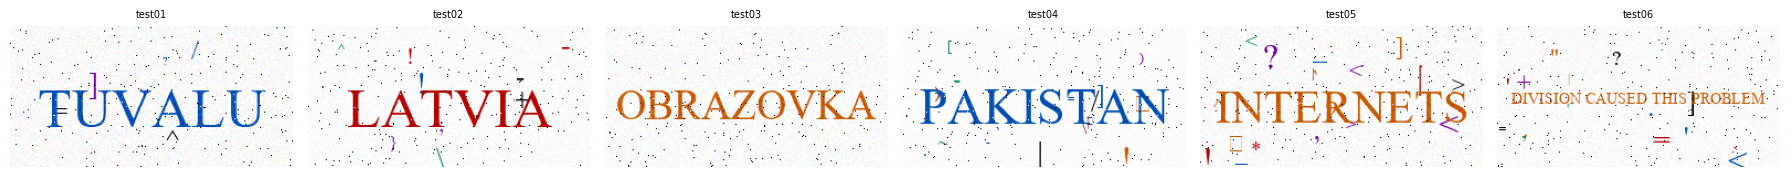

In [3]:
# Image visualization
import matplotlib.pyplot as plt

def show_images(ids: list, test_data: dict, ncols: int = 6) -> None:
    """Displays a list of images by datapointID."""
    ids = ids[:ncols]
    fig, axes = plt.subplots(1, len(ids), figsize=(3 * len(ids), 3))
    if len(ids) == 1:
        axes = [axes]
    for ax, pid in zip(axes, ids):
        img = decode_image(test_data[pid])
        ax.imshow(img)
        ax.set_title(pid, fontsize=7)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def show_single(datapoint_id: str, test_data: dict) -> np.ndarray:
    """Displays a single image and returns it as a numpy array."""
    img = decode_image(test_data[datapoint_id])
    plt.figure(figsize=(8, 4))
    plt.imshow(img)
    plt.title(datapoint_id)
    plt.axis("off")
    plt.show()
    print(f"Shape: {img.shape}")
    return img

# Display the first 6 images
show_images(list(test_data.keys())[:6], test_data)


Loaded 36 templates from letters
Embedded 36 templates as base64


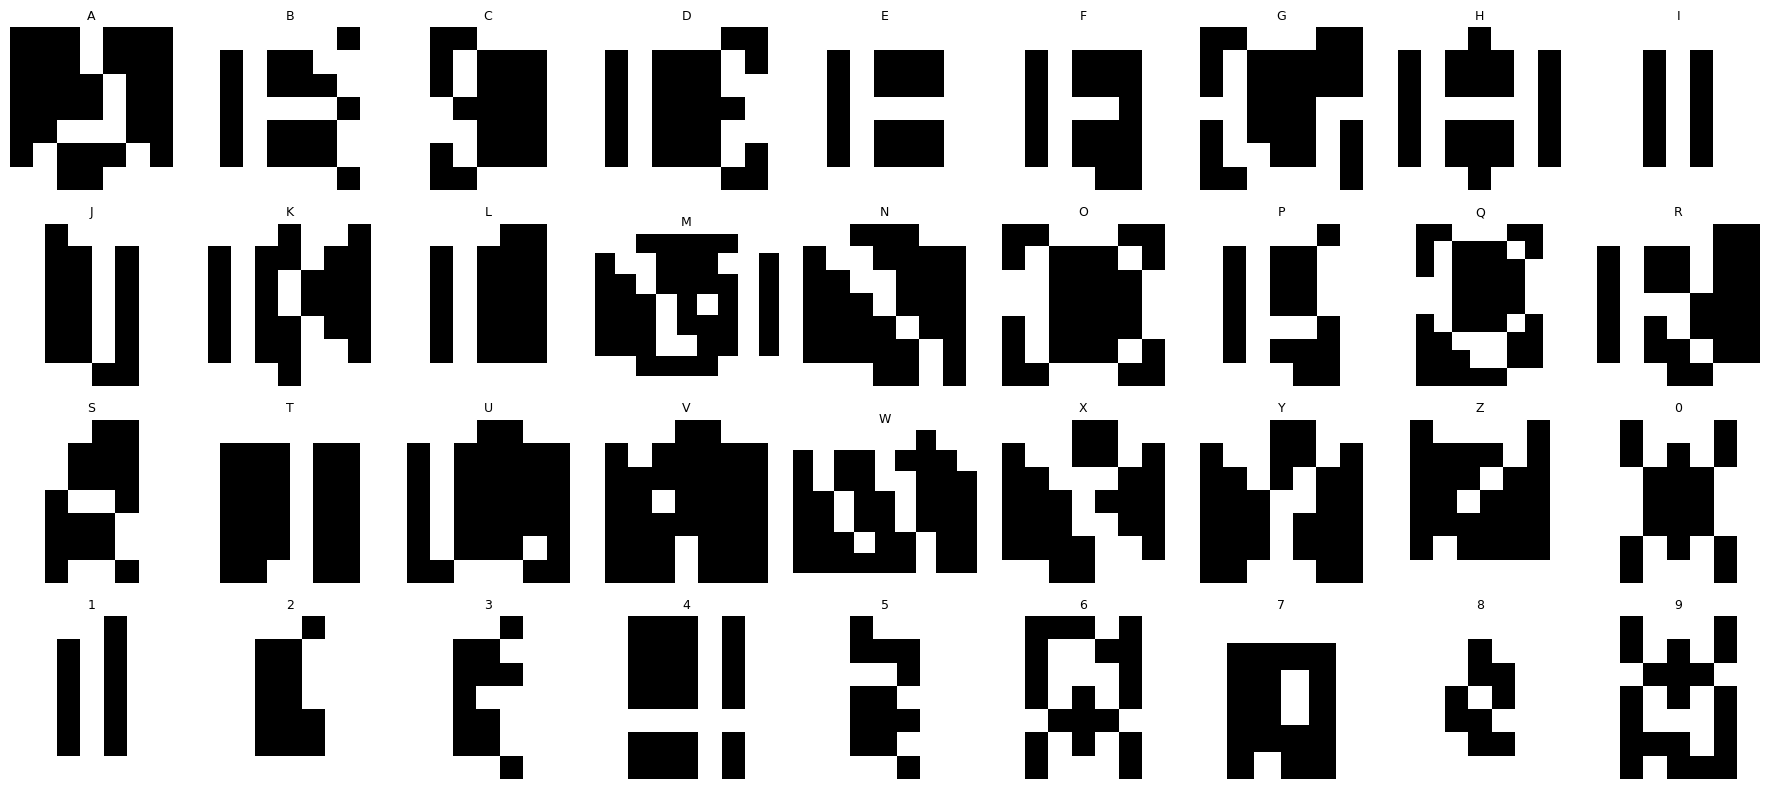

In [4]:
# Load letter templates
def tight_crop(binary: np.ndarray) -> np.ndarray:
    """Crops white margins from a binary image."""
    coords = np.argwhere(binary > 0)
    if len(coords) == 0:
        return np.zeros((1, 1), dtype=binary.dtype)
    y1, x1 = coords.min(axis=0)
    y2, x2 = coords.max(axis=0)
    return binary[y1:y2 + 1, x1:x2 + 1]

def _normalize_glyph(binary: np.ndarray, height: int = TMPL_SIZE,
                      max_width: int = TMPL_SIZE) -> np.ndarray:
    g = tight_crop(binary)
    gh, gw = g.shape[:2]
    if gh < 1 or gw < 1:
        return np.zeros((height, 2), dtype=np.float32)
    w = int(round(height * gw / gh))
    w = max(2, min(w, max_width))
    resized = cv2.resize(g, (w, height), interpolation=cv2.INTER_AREA)
    return resized.astype(np.float32) / 255.0

def load_templates(train_dir: str = TRAIN_DIR) -> dict:
    """Reads PNGs from train_dir and returns {char: binary_mask}."""
    templates = {}
    for ch in CHAR_ORDER:
        bgr = cv2.imread(os.path.join(train_dir, f"{ch}.png"))
        if bgr is None:
            continue
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        _, binary = cv2.threshold(
            gray, 127, 255,
            cv2.THRESH_BINARY_INV if gray.mean() > 128 else cv2.THRESH_BINARY
        )
        templates[ch] = tight_crop(binary)
    print(f"Loaded {len(templates)} templates from {train_dir}")
    return templates

def build_template_vecs(templates: dict, size: int = TMPL_SIZE) -> dict:
    """Returns {char: (glyph_float32, width, aspect_ratio)}."""
    vecs = {}
    for ch, tmpl in templates.items():
        g = _normalize_glyph(tmpl, height=size, max_width=size)
        w = g.shape[1]
        vecs[ch] = (g, w, w / float(size))
    return vecs

# Load from disk (local only)
templates     = load_templates()
template_vecs = build_template_vecs(templates)

# Embed as base64 for Submission (required in cloud, no disk access)
_TMPL_B64 = {}
for _ch in CHAR_ORDER:
    _path = os.path.join(TRAIN_DIR, f"{_ch}.png")
    with open(_path, "rb") as _fh:
        _TMPL_B64[_ch] = base64.b64encode(_fh.read()).decode()

print(f"Embedded {len(_TMPL_B64)} templates as base64")

# Visualize templates
fig, axes = plt.subplots(4, 9, figsize=(18, 8))
for ax, ch in zip(axes.flat, CHAR_ORDER):
    ax.imshow(templates[ch], cmap="gray")
    ax.set_title(ch, fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(CHAR_ORDER):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


In [5]:
# `Submission` Class
# Templates are embedded as base64 in `_TMPL_B64` → the class is fully self-contained
class Submission:
    """
    Nitro Cloud Model task – bytes in, bytes out.

    Templates (A-Z, 0-9) are embedded as base64 in _TMPL_B64.
    __init__() decodes them and builds template_vecs without any disk access.

    Request  : pickle of list[{"datapointID": str, "imageBase64": str}]
    Response : pickle of list[{"subtaskID": int, "datapointID": str, "answer": ...}]
    """

    _TMPL_B64 = _TMPL_B64   # embedded at class definition time

    def __init__(self):
        import base64 as _b64
        import cv2 as _cv2
        import numpy as _np

        _templates = {}
        for ch, b64str in self._TMPL_B64.items():
            raw = _b64.b64decode(b64str)
            arr = _np.frombuffer(raw, dtype=_np.uint8)
            bgr = _cv2.imdecode(arr, _cv2.IMREAD_COLOR)
            if bgr is None:
                continue
            gray = _cv2.cvtColor(bgr, _cv2.COLOR_BGR2GRAY)
            _, binary = _cv2.threshold(
                gray, 127, 255,
                _cv2.THRESH_BINARY_INV if gray.mean() > 128 else _cv2.THRESH_BINARY
            )
            _templates[ch] = tight_crop(binary)

        self.templates     = _templates
        self.template_vecs = build_template_vecs(_templates)

    def predict(self, img: np.ndarray) -> tuple:
        """
        Receives an RGB image and returns (subtask1, subtask2, subtask3).
        TODO: replace with your logic.
        """
        # Placeholder – returns dummy values
        text = "_"
        return 1, "_", text

    def __call__(self, data: bytes) -> bytes:
        try:
            import pickle as _pickle

            rows_in = _pickle.loads(data)   # list of {"datapointID", "imageBase64"}

            result = []
            for item in rows_in:
                pid = item["datapointID"]
                img = decode_image(item["imageBase64"])
                s1, s2, s3 = self.predict(img)
                result.append({"subtaskID": 1, "datapointID": pid, "answer": s1})
                result.append({"subtaskID": 2, "datapointID": pid, "answer": s2})
                result.append({"subtaskID": 3, "datapointID": pid, "answer": s3})

            return _pickle.dumps(result, protocol=4)

        except Exception:
            import traceback as _tb
            import pickle as _pickle
            return _pickle.dumps(RuntimeError(_tb.format_exc()), protocol=4)

print("Submission class defined")


Submission class defined


In [6]:
# Export submission.pkl
import cloudpickle

submission_obj = Submission()
pkl_path = os.path.join(BASE_DIR, "submission.pkl")
with open(pkl_path, "wb") as f:
    cloudpickle.dump(submission_obj, f)

print(f"Written {pkl_path}")


Written submission.pkl
